<a href="https://colab.research.google.com/github/saivasanthg/PruningModel_Tredence/blob/main/Pruning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:219: SyntaxWarning: invalid escape sequence '\l'
<>:219: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2151/2150613580.py:219: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Distribution of Final Gate Values ($\lambda$ = {best_lambda})', fontsize=14, fontweight='bold')


Loading Data...

🚀 TESTING LAMBDA: 0.001 (Raw L1 - No Cap)
Epoch  0 | [Warmup ] | Loss:  2.0464 | Acc: 34.40% | Sparsity:  0.00%
Epoch  1 | [Warmup ] | Loss:  1.8605 | Acc: 37.00% | Sparsity:  0.00%
Epoch  2 | [Warmup ] | Loss:  1.7911 | Acc: 38.43% | Sparsity:  0.00%
Epoch  3 | [Warmup ] | Loss:  1.7415 | Acc: 40.59% | Sparsity:  0.00%
Epoch  4 | [Warmup ] | Loss:  1.6992 | Acc: 41.19% | Sparsity:  0.00%
Epoch  5 | [TAX ON ] | Loss:  3.4326 | Acc: 41.86% | Sparsity:  0.00%
Epoch  6 | [TAX ON ] | Loss:  3.3125 | Acc: 43.17% | Sparsity:  0.00%
Epoch  7 | [TAX ON ] | Loss:  3.1986 | Acc: 43.21% | Sparsity:  0.00%
Epoch  8 | [TAX ON ] | Loss:  3.0906 | Acc: 43.33% | Sparsity:  0.00%
Epoch  9 | [TAX ON ] | Loss:  2.9881 | Acc: 44.31% | Sparsity:  0.00%
Epoch 10 | [TAX ON ] | Loss:  2.8918 | Acc: 44.32% | Sparsity:  0.00%
Epoch 11 | [TAX ON ] | Loss:  2.8007 | Acc: 43.93% | Sparsity:  0.00%
Epoch 12 | [TAX ON ] | Loss:  2.7148 | Acc: 44.37% | Sparsity:  0.00%
Epoch 13 | [TAX ON ] | Loss:  2

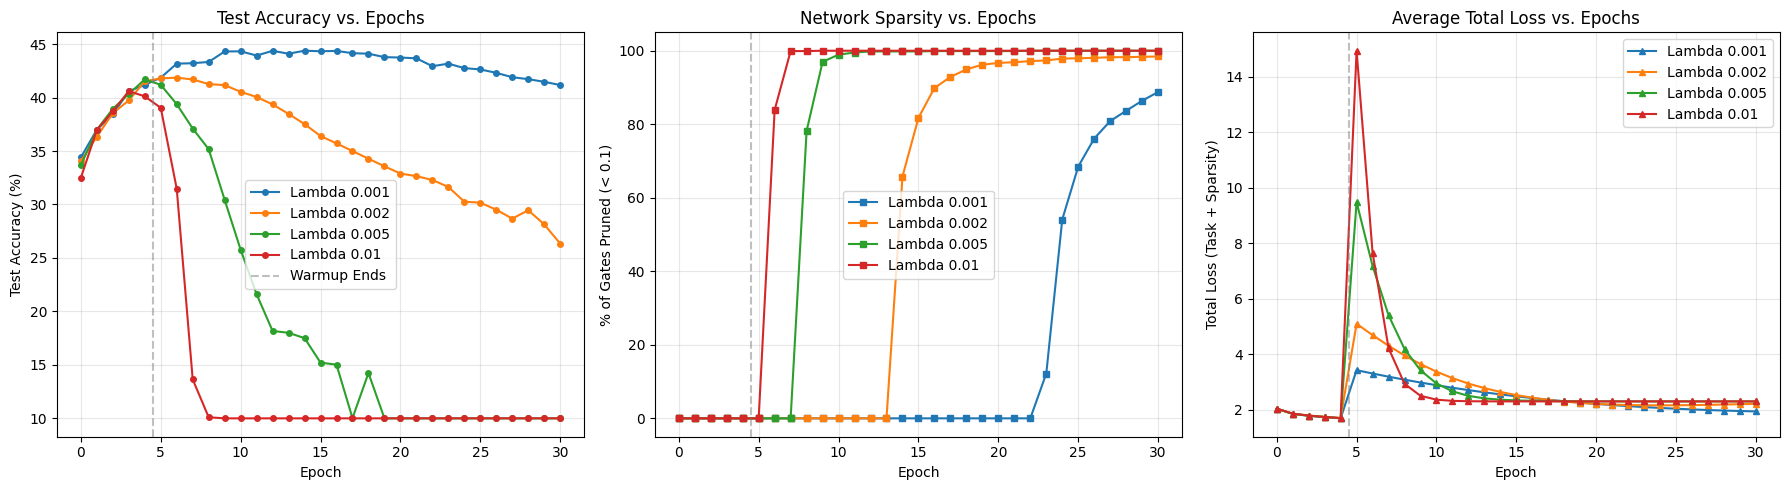

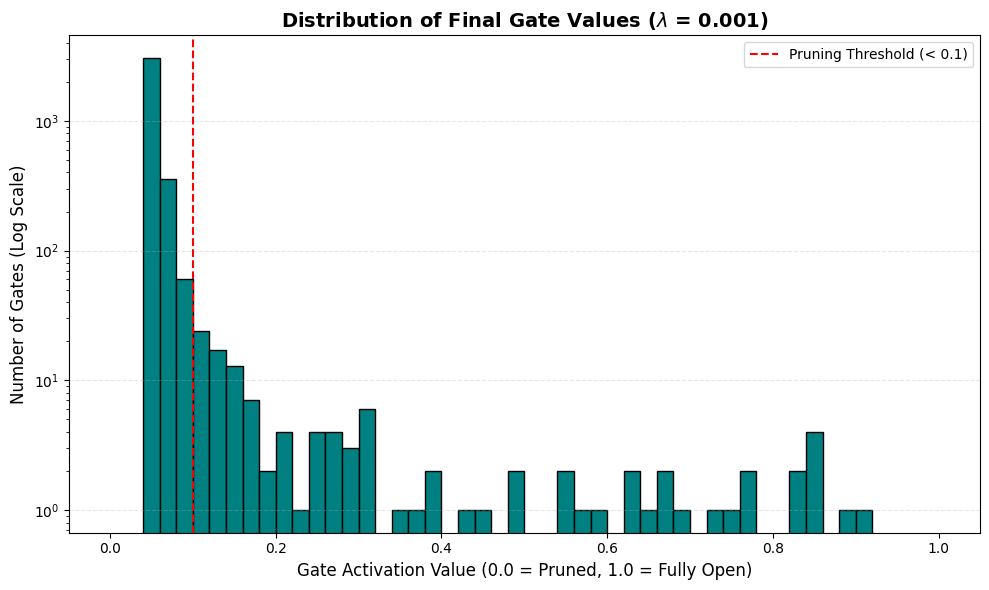

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train_proc = x_train.reshape(x_train.shape[0], -1).astype(np.float32) / 255.0
x_test_proc = x_test.reshape(x_test.shape[0], -1).astype(np.float32) / 255.0
y_train_oh = np.eye(10)[y_train.flatten()]
y_test_oh = np.eye(10)[y_test.flatten()]

def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
def relu(x): return np.maximum(0, x)
def relu_deriv(x): return (x > 0).astype(float)
def softmax(x):
    shift_x = x - np.max(x, axis=1, keepdims=True)
    exps = np.exp(shift_x)
    return exps / np.sum(exps, axis=1, keepdims=True)

class PrunableLayer:
    def __init__(self, in_f, out_f):
        self.w = np.random.randn(in_f, out_f) * np.sqrt(2 / in_f)
        self.biases = np.zeros((1, out_f))
        self.gate_score = np.zeros((in_f, 1))

        self.gate_act = sigmoid(self.gate_score)

        self.dw, self.db = np.zeros_like(self.w), np.zeros_like(self.biases)

    def forward(self, x):
        self.x = x
        self.gate_act = sigmoid(self.gate_score)
        self.eff_w = self.w * self.gate_act
        return np.dot(x, self.eff_w) + self.biases

    def backward(self, d_out):
        self.dw = np.dot(self.x.T, d_out) * self.gate_act
        self.db = np.sum(d_out, axis=0, keepdims=True)
        sig_d = self.gate_act * (1 - self.gate_act)
        self.d_gate_task = np.sum(np.dot(self.x.T, d_out) * self.w, axis=1, keepdims=True) * sig_d
        return np.dot(d_out, self.eff_w.T)

class CrossEntropyLoss:
    def __init__(self): self.probs = None
    def forward(self, probs, targets):
        self.probs = np.clip(probs, 1e-7, 1.0 - 1e-7)
        return -np.mean(np.sum(targets * np.log(self.probs), axis=1))
    def backward(self, targets):
        return (self.probs - targets) / targets.shape[0]

class SGDMomentum:
    def __init__(self, lr=0.005, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v_w = {}
        self.v_b = {}

    def step(self, layer, layer_id):
        if layer_id not in self.v_w:
            self.v_w[layer_id] = np.zeros_like(layer.w)
            self.v_b[layer_id] = np.zeros_like(layer.biases)

        self.v_w[layer_id] = self.momentum * self.v_w[layer_id] - self.lr * layer.dw
        self.v_b[layer_id] = self.momentum * self.v_b[layer_id] - self.lr * layer.db

        layer.w += self.v_w[layer_id]
        layer.biases += self.v_b[layer_id]


lambdas_to_test = [0.001, 0.002, 0.005, 0.01]
all_results = {}

epochs = 30
gate_lr = 0.3
batch_size = 128
num_batches = x_train_proc.shape[0] // batch_size

for lam in lambdas_to_test:


    dims = [3072, 512, 10]
    network = [PrunableLayer(dims[0], dims[1]), PrunableLayer(dims[1], dims[2])]
    loss_fn = CrossEntropyLoss()
    weight_opt = SGDMomentum(lr=0.005, momentum=0.9)

    history = {'epoch': [], 'acc': [], 'sparsity': [], 'loss': [], 'final_gates': []}

    for epoch in range(epochs + 1):
        indices = np.random.permutation(50000)
        epoch_total_loss = 0

        for i in range(0, 50000, batch_size):
            idx = indices[i:i+batch_size]
            x_b, y_b = x_train_proc[idx], y_train_oh[idx]

            if epoch < 5:
                active_lambda = 0.0
            else:
                active_lambda = lam

            a1 = relu(network[0].forward(x_b))
            probs = softmax(network[1].forward(a1))
            task_loss = loss_fn.forward(probs, y_b)
            sparsity_loss = np.sum([np.sum(l.gate_act) for l in network])
            batch_loss = task_loss + (active_lambda * sparsity_loss)
            epoch_total_loss += batch_loss
            d_err = loss_fn.backward(y_b)
            d_a1 = network[1].backward(d_err) * relu_deriv(a1)
            network[0].backward(d_a1)

            for j, layer in enumerate(network):
                weight_opt.step(layer, j)
                layer.gate_score -= gate_lr * (layer.d_gate_task + active_lambda)

        test_z = x_test_proc
        for j, layer in enumerate(network):
            test_z = layer.forward(test_z)
            if j < len(network) - 1: test_z = relu(test_z)

        test_acc = np.mean(np.argmax(softmax(test_z), axis=1) == np.argmax(y_test_oh, axis=1)) * 100
        final_epoch_sparsity = np.mean([np.mean(l.gate_act < 0.1) for l in network]) * 100
        avg_epoch_loss = epoch_total_loss / num_batches

        flat_gates = np.concatenate([layer.gate_act.flatten() for layer in network])

        phase = "Warmup " if epoch < 5 else "TAX ON "
        print(f"Epoch {epoch:2} | [{phase}] | Loss: {avg_epoch_loss:7.4f} | Acc: {test_acc:5.2f}% | Sparsity: {final_epoch_sparsity:5.2f}%")

        history['epoch'].append(epoch)
        history['acc'].append(test_acc)
        history['sparsity'].append(final_epoch_sparsity)
        history['loss'].append(avg_epoch_loss)
        history['final_gates'].append(flat_gates)

    all_results[lam] = history



print("\nGenerating Presentation Plots...")

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
for lam, hist in all_results.items():
    plt.plot(hist['epoch'], hist['acc'], marker='o', markersize=4, label=f'Lambda {lam}')
plt.axvline(x=4.5, color='gray', linestyle='--', alpha=0.5, label='Warmup Ends')
plt.title('Test Accuracy vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
for lam, hist in all_results.items():
    plt.plot(hist['epoch'], hist['sparsity'], marker='s', markersize=4, linestyle='-', label=f'Lambda {lam}')
plt.axvline(x=4.5, color='gray', linestyle='--', alpha=0.5)
plt.title('Network Sparsity vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('% of Gates Pruned (< 0.1)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
for lam, hist in all_results.items():
    plt.plot(hist['epoch'], hist['loss'], marker='^', markersize=4, linestyle='-', label=f'Lambda {lam}')
plt.axvline(x=4.5, color='gray', linestyle='--', alpha=0.5)
plt.title('Average Total Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Total Loss (Task + Sparsity)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_lambda = 0.001
final_gate_values = all_results[best_lambda]['final_gates'][-1]

plt.figure(figsize=(10, 6))
plt.hist(final_gate_values, bins=50, range=(0, 1), color='teal', edgecolor='black')

plt.title(f'Distribution of Final Gate Values ($\lambda$ = {best_lambda})', fontsize=14, fontweight='bold')
plt.xlabel('Gate Activation Value (0.0 = Pruned, 1.0 = Fully Open)', fontsize=12)
plt.ylabel('Number of Gates (Log Scale)', fontsize=12)
plt.yscale('log')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.axvline(x=0.1, color='red', linestyle='--', label='Pruning Threshold (< 0.1)')
plt.legend()

plt.tight_layout()
plt.show()